# Arène des Algos

## Phase 0 : Mise en route

In [1]:
print("Hello")

Hello


In [2]:
#!pip install scikit-learn pandas numpy matplotlib ipykernel

In [3]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sys

print("Python      :", sys.version)
print("scikit-learn:", sklearn.__version__)
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("matplotlib  :", matplotlib.__version__)

Python      : 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
scikit-learn: 1.9.0
pandas      : 3.0.3
numpy       : 2.4.6
matplotlib  : 3.10.9


## Phase A : Prédire les prix immobiliers (régression)

In [10]:
from sklearn.datasets import fetch_california_housing

def charger_immobilier():
    """Charge California Housing, renvoie X, y."""
    dataset = fetch_california_housing()
    X, y = dataset.data, dataset.target
    print("Lignes x variables :", X.shape)
    print("Variables :", dataset.feature_names)
    print("Cible : prix médian en centaines de milliers de $")
    return X, y

X, y = charger_immobilier()

Lignes x variables : (20640, 8)
Variables : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Cible : prix médian en centaines de milliers de $


Evaluation

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

def evaluer_regression(modele, X_train, X_test, y_train, y_test):
    """Entraîne, prédit, renvoie un dict {r2, mae, rmse}."""
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    return {
        "R2"  : round(r2_score(y_train, modele.predict(X_train)), 4),  # train (surapprentissage ?)
        "R2"  : round(r2_score(y_test, y_pred), 4),
        "mae" : round(mean_absolute_error(y_test, y_pred), 4),
        "rmse": round(root_mean_squared_error(y_test, y_pred), 4),
    }

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

X, y = charger_immobilier()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modeles = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LinearRegression()),
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestRegressor(n_estimators=100, random_state=42)),
    ]),
}

resultats_A = {}
for nom, modele in modeles.items():
    resultats_A[nom] = evaluer_regression(modele, X_train, X_test, y_train, y_test)
    print(f"{nom:20s} : {resultats_A[nom]}")

Lignes x variables : (20640, 8)
Variables : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Cible : prix médian en centaines de milliers de $
LinearRegression     : {'R2': 0.5758, 'mae': 0.5332, 'rmse': 0.7456}
RandomForest         : {'R2': 0.8047, 'mae': 0.3278, 'rmse': 0.5059}


Visualisation

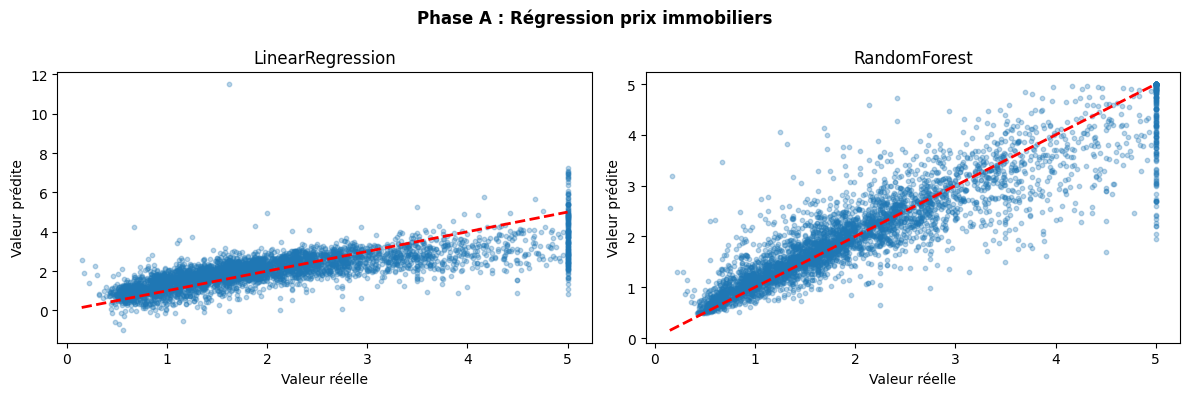

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (nom, modele) in zip(axes, modeles.items()):
    y_pred = modele.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--", lw=2)
    ax.set_title(nom)
    ax.set_xlabel("Valeur réelle")
    ax.set_ylabel("Valeur prédite")

plt.suptitle("Phase A : Régression prix immobiliers", fontweight="bold")
plt.tight_layout()
plt.show()

### Checkpoint qualité

In [16]:
from sklearn.base import clone
import numpy as np

In [ ]:
print("CAS NORMAL")
for nom, scores in resultats_A.items():
    print(f"{nom:20s} : {scores}")

print()
print("CAS LIMITE : 100 lignes d'entraînement")

X_train_small = X_train[:100]
y_train_small = y_train[:100]

resultats_limite = {}
for nom, modele in modeles.items():
    # Réinitialiser le pipeline pour repartir de zéro
    modele_clone = clone(modele)
    scores = evaluer_regression(modele_clone, X_train_small, X_test, y_train_small, y_test)
    resultats_limite[nom] = scores
    print(f"{nom:20s} : {scores}")

print()
print("CAS ADVERSARIAL : quartier fictif")
print("Revenu médian = 0, population = 9000, autres variables = moyennes du dataset\n")

# Variables : MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
moyennes = X_train.mean(axis=0)
quartier_fictif = moyennes.copy()
quartier_fictif[0] = 0      # MedInc = 0
quartier_fictif[4] = 9000   # Population = 9000

quartier_fictif_2d = quartier_fictif.reshape(1, -1)

print(f"{'Variable':<12} {'Valeur':>10}")
feature_names = fetch_california_housing().feature_names
for nom_var, val in zip(feature_names, quartier_fictif):
    print(f"{nom_var:<12} {val:>10.2f}")

for nom, modele in modeles.items():
    pred = modele.predict(quartier_fictif_2d)[0]
    coherent = pred >= 0
    print(f"{nom:20s} : {pred:.4f} {'cohérent' if coherent else 'valeur négative'}")


CAS NORMAL
LinearRegression     : {'R2': 0.5758, 'mae': 0.5332, 'rmse': 0.7456}
RandomForest         : {'R2': 0.8047, 'mae': 0.3278, 'rmse': 0.5059}

CAS LIMITE : 100 lignes d'entraînement
LinearRegression     → {'R2': 0.4046, 'mae': 0.5352, 'rmse': 0.8833}
RandomForest         → {'R2': 0.5445, 'mae': 0.5599, 'rmse': 0.7726}

CAS ADVERSARIAL : quartier fictif
Revenu médian = 0, population = 9000, autres variables = moyennes du dataset

Variable         Valeur
MedInc             0.00
HouseAge          28.61
AveRooms           5.44
AveBedrms          1.10
Population      9000.00
AveOccup           3.10
Latitude          35.64
Longitude       -119.58
LinearRegression     : 0.3154 cohérent
RandomForest         : 0.6443 cohérent


## Phase B : Segmenter les clients AirBnB (clustering)

In [32]:
def charger_airbnb(path_csv):
    df = pd.read_csv(path_csv, compression="gzip" if path_csv.endswith(".gz") else None)
    
    # Price supprimé par Inside Airbnb — on clustérise sur des proxies pertinents
    colonnes = [
        "minimum_nights",
        "number_of_reviews",
        "availability_365",
        "review_scores_rating",
        "accommodates",
        "bedrooms",
    ]
    df = df[colonnes].copy()
    df = df.dropna()
    df = df[df["minimum_nights"] > 0]
    
    print(f"Listings chargés : {len(df)} lignes, {len(colonnes)} colonnes numériques retenues")
    return df

URL_CSV = "data/listings.csv.gz"
df_airbnb = charger_airbnb(URL_CSV)
df_airbnb.describe()

Listings chargés : 51512 lignes, 6 colonnes numériques retenues


,minimum_nights,number_of_reviews,availability_365,review_scores_rating,accommodates,bedrooms
count,51512.000000,51512.000000,51512.000000,51512.000000,51512.000000,51512.000000
mean,31.079302,32.766365,125.654896,4.743749,3.479985,1.445877
std,92.767379,63.415091,132.660068,0.384911,1.733834,0.816383
min,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,2.000000,4.000000,0.000000,4.670000,2.000000,1.000000
50%,3.000000,13.000000,74.000000,4.850000,3.000000,1.000000
75%,5.000000,36.000000,256.000000,5.000000,4.000000,2.000000
max,1000.000000,4040.000000,365.000000,5.000000,16.000000,33.000000


Standardisation

In [33]:
from sklearn.preprocessing import StandardScaler

scaler_airbnb = StandardScaler()
X_airbnb = scaler_airbnb.fit_transform(df_airbnb)

print("Moyenne après scaling (~0) :", X_airbnb.mean(axis=0).round(4))
print("Écart-type après scaling (~1):", X_airbnb.std(axis=0).round(4))

Moyenne après scaling (~0) : [ 0.  0.  0.  0. -0.  0.]
Écart-type après scaling (~1): [1. 1. 1. 1. 1. 1.]


Choisir k

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def choisir_k(X_scaled, k_range=range(2, 9)):
    resultats = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X_scaled)
        inertie = int(km.inertia_)
        silhouette = round(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42), 2)
        print(f"k={k} : inertie={inertie:<8} silhouette={silhouette}")
        resultats.append((k, inertie, silhouette))
    return resultats

resultats_k = choisir_k(X_airbnb)

k=2 : inertie=251158   silhouette=0.3
k=3 : inertie=201288   silhouette=0.36
k=4 : inertie=168188   silhouette=0.32
k=5 : inertie=144927   silhouette=0.33
k=6 : inertie=122127   silhouette=0.34
k=7 : inertie=111576   silhouette=0.33
k=8 : inertie=102548   silhouette=0.33


Visualisation coude + silhouette

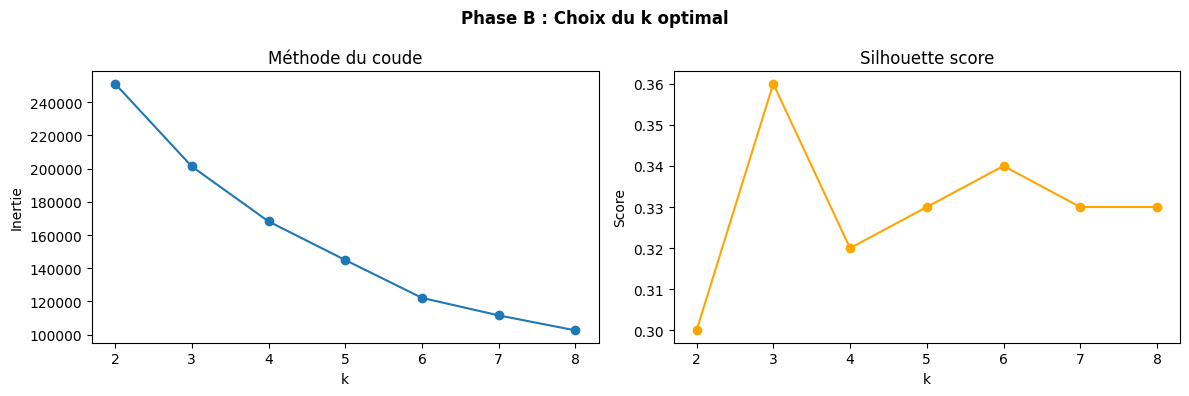


Segment retenu : k=3


In [35]:
import matplotlib.pyplot as plt

ks          = [r[0] for r in resultats_k]
inerties    = [r[1] for r in resultats_k]
silhouettes = [r[2] for r in resultats_k]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ks, inerties, marker="o")
ax1.set_title("Méthode du coude")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertie")

ax2.plot(ks, silhouettes, marker="o", color="orange")
ax2.set_title("Silhouette score")
ax2.set_xlabel("k")
ax2.set_ylabel("Score")

plt.suptitle("Phase B : Choix du k optimal", fontweight="bold")
plt.tight_layout()
plt.show()

k_retenu = ks[silhouettes.index(max(silhouettes))]
print(f"\nSegment retenu : k={k_retenu}")

Entraînement final + description

In [37]:
km_final = KMeans(n_clusters=k_retenu, n_init=10, random_state=42)
df_airbnb["segment"] = km_final.fit_predict(X_airbnb)

print("Description des segments\n")
desc = df_airbnb.groupby("segment").agg(
    nb_listings      = ("minimum_nights", "count"),
    nuits_min_moy    = ("minimum_nights", "mean"),
    avis_moyen       = ("number_of_reviews", "mean"),
    dispo_moy        = ("availability_365", "mean"),
    note_moy         = ("review_scores_rating", "mean"),
    capacite_moy     = ("accommodates", "mean"),
    chambres_moy     = ("bedrooms", "mean"),
).round(1)
print(desc)

Description des segments

         nb_listings  nuits_min_moy  avis_moyen  dispo_moy  note_moy  \
segment                                                                
0              37095            6.1        32.3      115.3       4.8   
1               3608          365.2        10.2       47.0       4.7   
2              10809            5.4        41.8      187.5       4.7   

         capacite_moy  chambres_moy  
segment                              
0                 2.8           1.1  
1                 3.2           1.3  
2                 5.9           2.6  


Checkpoint qualité

In [40]:
from sklearn.base import clone

print("CAS NORMAL")
print(f"k retenu : {k_retenu}\n")

# Cas limite : sans standardiser
print("CAS LIMITE : KMeans SANS standardisation")
km_raw    = KMeans(n_clusters=k_retenu, n_init=10, random_state=42)
labels_raw = km_raw.fit_predict(df_airbnb[["minimum_nights","number_of_reviews",
                                            "availability_365","review_scores_rating",
                                            "accommodates","bedrooms"]])
sil_raw   = round(silhouette_score(
    df_airbnb[["minimum_nights","number_of_reviews","availability_365",
               "review_scores_rating","accommodates","bedrooms"]],
    labels_raw, sample_size=5000, random_state=42), 4)
print(f"Silhouette sans scaling : {sil_raw}")
print(f"Silhouette avec scaling : {max(silhouettes)}")

# Cas adversarial : annonce aberrante
print("\nCAS ADVERSARIAL : annonce à 1000 nuits minimum")
annonce = pd.DataFrame([{
    "minimum_nights": 1000,
    "number_of_reviews": 0,
    "availability_365": 365,
    "review_scores_rating": 0,
    "accommodates": 1,
    "bedrooms": 0,
}])
annonce_scaled   = scaler_airbnb.transform(annonce)
segment_aberrant = km_final.predict(annonce_scaled)[0]
distances        = km_final.transform(annonce_scaled)[0]
print(f"Assignée au segment : {segment_aberrant}")
print(f"Distances aux centres : {distances.round(2)}")

CAS NORMAL
k retenu : 3

CAS LIMITE : KMeans SANS standardisation
Silhouette sans scaling : 0.6511
Silhouette avec scaling : 0.36

CAS ADVERSARIAL : annonce à 1000 nuits minimum
Assignée au segment : 1
Distances aux centres : [16.55 14.32 16.92]
